In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
y = y.ravel()

In [4]:
b = -150
m = 27.82  # Assuming slope is constant as per your code
lr = 0.001
epochs = 30
all_b = []
all_cost = []

In [5]:
for i in range(epochs):
    slope = -2 * np.sum(y - (m * X.ravel()) - b)
    cost = np.sum((y - (m * X.ravel()) - b)**2)
    
    b = b - (lr * slope)
    all_b.append(b)
    all_cost.append(cost)

In [6]:
b_input = np.linspace(-150, 50, 100)
cost_input = []
for b_val in b_input:
    # Calculate what the cost would be for every possible 'b' from -150 to 50
    this_cost = np.sum((y - (m * X.ravel()) - b_val)**2)
    cost_input.append(this_cost)

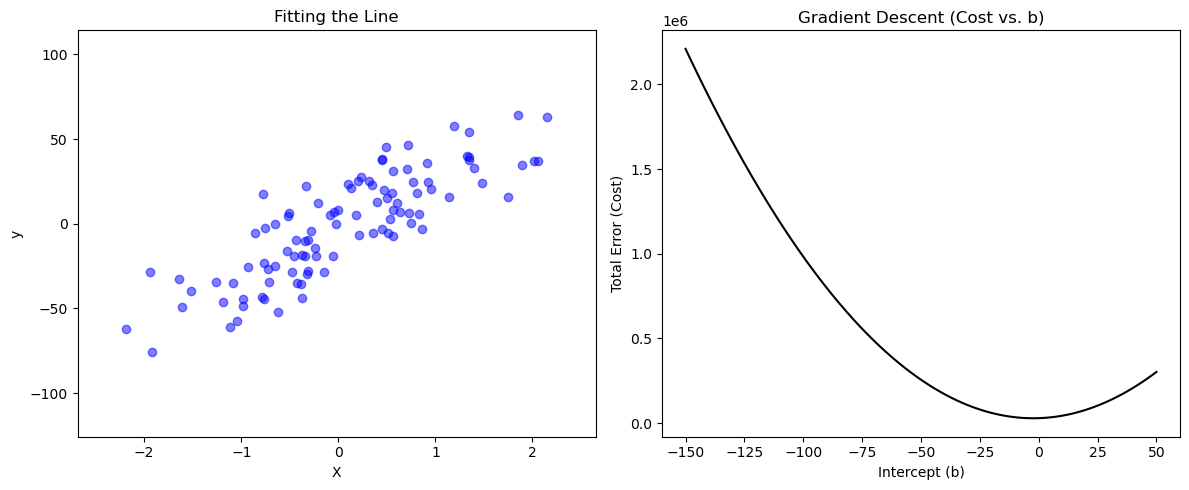

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left Graph: The Line Fit ---
ax1.scatter(X, y, color='blue', alpha=0.5)
line1, = ax1.plot([], [], color='red', lw=2)
ax1.set_title("Fitting the Line")
ax1.set_xlabel("X")
ax1.set_ylabel("y")
ax1.set_xlim(X.min() - 0.5, X.max() + 0.5)
ax1.set_ylim(y.min() - 50, y.max() + 50)

# --- Right Graph: The Cost Curve ---
ax2.plot(b_input, cost_input, color='black', lw=1.5) # The background U-shape
dot, = ax2.plot([], [], 'ro', markersize=8)          # The moving red dot
ax2.set_title("Gradient Descent (Cost vs. b)")
ax2.set_xlabel("Intercept (b)")
ax2.set_ylabel("Total Error (Cost)")

plt.tight_layout()

In [8]:
def animate(i):
    # Update the red line on the left graph
    y_pred = m * X.ravel() + all_b[i]
    line1.set_data(X.ravel(), y_pred)
    
    # Update the position of the red dot on the right graph
    dot.set_data([all_b[i]], [all_cost[i]])
    
    # Dynamically update the main title so you can see the numbers changing
    fig.suptitle(f"Epoch: {i+1} | Current b: {all_b[i]:.2f}", fontsize=14, fontweight='bold', y=1.05)
    
    return line1, dot

In [9]:
anim = FuncAnimation(fig, animate, frames=epochs, interval=200, blit=True)

print("Processing animation... This may take a few seconds.")
anim.save("gradient_descent(b).gif", writer=PillowWriter(fps=5))
print("Done! Saved as gradient_descent(b).gif")

Processing animation... This may take a few seconds.
Done! Saved as gradient_descent(b).gif
